# Analyse du renouvellement des élu.e.s municipaux suite aux éléctions 2026

## Initialisation et import

### Prérequis

1. Installe les librairies nécessaires (à lancer une seule fois dans un terminal, ou dans une cellule avec `!` devant) :
```
pip install pandas matplotlib requests
```

2. Télécharge ces deux fichiers CSV **depuis ton navigateur** (le téléchargement automatisé est bloqué par data.gouv.fr) et place-les dans le même dossier que ce notebook :
   - Conseillers municipaux **sortants** (avant l'élection) : https://www.data.gouv.fr/api/1/datasets/r/bfb340ee-5068-4706-b07c-1ab7b0e2fd5b
   - Conseillers municipaux **actuels** (élus mars 2026) : https://www.data.gouv.fr/api/1/datasets/r/d5f400de-ae3f-4966-8cb6-a85c70c6c24a

   Renomme-les si besoin `conseillers_sortants.csv` et `conseillers_actuels.csv`, ou adapte les chemins dans la cellule suivante.

### Importations des modules et des fichiers de données

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import numpy as np

FICHIER_SORTANTS = "mun2026-cm-sortants-20260227.csv"
FICHIER_ACTUELS = "elus-conseillers-municipaux-cm.csv"

# On charge les deux fichiers en `dtype=str` (tout en texte) pour éviter que pandas ne déforme les codes communes (ex: `01234` ne doit pas devenir `1234`).
# `sep=None, engine="python"` fait détecter automatiquement le séparateur (souvent `;` pour les fichiers du Ministère de l'Intérieur).

sortants = pd.read_csv(FICHIER_SORTANTS, sep=None, engine="python", dtype=str)
actuels = pd.read_csv(FICHIER_ACTUELS, sep=None, engine="python", dtype=str)

#En cas de problemes, afficher le nom exact des colonnes ui servent pour la suite.

# print("Colonnes SORTANTS :", list(sortants.columns))
# print("Colonnes ACTUELS  :", list(actuels.columns))
# sortants.head()

### Adaptation des noms de colonnes et la date


Reporte ici les noms EXACTS vus dans la sortie de l'étape 1 (copier-coller pour éviter les fautes de frappe/accents).

In [20]:
COL_CODE_COMMUNE = "Code de la commune"
COL_NOM = "Nom de l'élu"
COL_PRENOM = "Prénom de l'élu"
COL_NAISSANCE = "Date de naissance"

In [21]:
code_test = sorted(set(sortants[COL_CODE_COMMUNE]) & set(actuels[COL_CODE_COMMUNE]))[0]
print("Commune testée :", code_test)

print("\n--- SORTANTS ---")
print(sortants.loc[sortants[COL_CODE_COMMUNE] == code_test, [COL_NOM, COL_PRENOM, COL_NAISSANCE]].head(3))

print("\n--- ACTUELS ---")
print(actuels.loc[actuels[COL_CODE_COMMUNE] == code_test, [COL_NOM, COL_PRENOM, COL_NAISSANCE]].head(3))

Commune testée : 10002

--- SORTANTS ---
      Nom de l'élu Prénom de l'élu Date de naissance
38643     BEAUJOIN     Jean-Michel          01/04/65
38644      BOITEUX            Axel          29/10/01
38645      BOITEUX       Sébastien          26/07/72

--- ACTUELS ---
      Nom de l'élu Prénom de l'élu Date de naissance
41184         BEAU         Martine        1968-03-12
41185     BEAUJOIN       Christine        1968-04-19
41186     BEAUJOIN     Jean-Michel        1965-04-01


### Construire une clé d'identité par élu


Comme il n'y a pas d'identifiant unique commun aux deux fichiers, on identifie chaque élu par la combinaison **commune + nom + prénom + date de naissance** (normalisée en majuscules, sans espaces superflus). C'est une approximation raisonnable — pas parfaite en cas d'homonymie exacte, mais suffisante pour une vue d'ensemble statistique.

In [22]:
import unicodedata

def sans_accents(s):
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")

def parse_date_flexible(series):
    """Gère les deux formats rencontrés : ISO (YYYY-MM-DD) et JJ/MM/AA (année sur 2 chiffres)."""
    # essai 1 : format ISO
    dates = pd.to_datetime(series, format="%Y-%m-%d", errors="coerce")

    # essai 2, pour les valeurs non reconnues : JJ/MM/AA
    manquantes = dates.isna()
    dates_courtes = pd.to_datetime(series[manquantes], format="%d/%m/%y", errors="coerce")

    # correction du pivot d'année : une date "dans le futur" (ex: 2065)
    # doit en réalité être reculée de 100 ans (1965)
    dans_le_futur = dates_courtes.dt.year > pd.Timestamp.now().year
    dates_courtes.loc[dans_le_futur] = dates_courtes.loc[dans_le_futur] - pd.DateOffset(years=100)

    dates.loc[manquantes] = dates_courtes
    return dates.dt.strftime("%Y-%m-%d")

def cle_identite(df):
    naissance = parse_date_flexible(df[COL_NAISSANCE])
    nom = df[COL_NOM].fillna("").apply(sans_accents).str.upper().str.strip()
    prenom = df[COL_PRENOM].fillna("").apply(sans_accents).str.upper().str.strip()
    commune = df[COL_CODE_COMMUNE].str.strip()
    return commune + "_" + nom + "_" + prenom + "_" + naissance.fillna("DATE_INCONNUE")

sortants["cle"] = cle_identite(sortants)
actuels["cle"] = cle_identite(actuels)

cles_sortants = set(sortants["cle"])
actuels["est_nouveau"] = ~actuels["cle"].isin(cles_sortants)

print(f"{actuels['est_nouveau'].mean() * 100:.1f} % des élus actuels sont nouveaux (moyenne nationale)")

59.4 % des élus actuels sont nouveaux (moyenne nationale)


### Agrégation par commune : le taux de renouvellement (%)

In [23]:
taux_par_commune = (
    actuels.groupby(COL_CODE_COMMUNE)["est_nouveau"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={COL_CODE_COMMUNE: "code_insee", "est_nouveau": "taux_renouvellement"})
)
taux_par_commune.head()

,code_insee,taux_renouvellement
0,10002,45.454545
1,10003,41.379310
2,10004,44.444444
3,10005,54.545455
4,10006,60.869565


### Ajout de la population par communes


Un seul appel à l'API Géo (gratuite, sans clé) suffit à récupérer nom, code INSEE et population de toutes les communes de France.

In [24]:
resp = requests.get(
    "https://geo.api.gouv.fr/communes",
    params={"fields": "nom,code,population", "format": "json"},
)
communes = pd.DataFrame(resp.json())[["code", "nom", "population"]]
communes = communes.rename(columns={"code": "code_insee"})
communes.head()

,code_insee,nom,population
0,01001,L'Abergement-Clémenciat,860.0
1,01002,L'Abergement-de-Varey,270.0
2,01004,Ambérieu-en-Bugey,15934.0
3,01005,Ambérieux-en-Dombes,1906.0
4,01006,Ambléon,115.0


Ensuite on fait la fusion sur le même tableau pour avoir taux de renouvellement + population

In [25]:
df = taux_par_commune.merge(communes, on="code_insee", how="inner")
df = df.dropna(subset=["population", "taux_renouvellement"])
df = df[df["population"] > 0]  # indispensable pour l'échelle log (log(0) impossible)

print(f"{len(df)} communes avec données complètes sur {len(communes)} au total")
df.describe()

31739 communes avec données complètes sur 34969 au total


,taux_renouvellement,population
count,31739.000000,3.173900e+04
mean,54.693077,2.048021e+03
std,18.772327,1.553252e+04
min,0.000000,2.000000e+00
25%,42.424242,2.050000e+02
50%,54.545455,4.760000e+02
75%,66.666667,1.228000e+03
max,100.000000,2.103778e+06


### Ajout d'une colonne de groupe de taille de communes

In [35]:
# 1. Nettoyage
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df = df.dropna(subset=['population', 'taux_renouvellement'])

# 2. Recatégorisation avec seuils légaux
bins = [0, 500, 1000, 2000, 5000, 10000, 30000, float('inf')]
labels = ['<500', '500-1k', '1k-2k', '2k-5k', '5k-10k', '10k-30k', '>30k']
df['groupe_taille'] = pd.cut(df['population'], bins=bins, labels=labels, right=False)

# 3. Vérification
print("Nouveaux groupes :")
print(df['groupe_taille'].value_counts().sort_index())


Nouveaux groupes :
groupe_taille
<500       16261
500-1k      6043
1k-2k       4185
2k-5k       3083
5k-10k      1161
10k-30k      728
>30k         278
Name: count, dtype: int64


### Vérification avant analyse

In [36]:
print("🔍 Vérification des données :")
print("-" * 50)

# Affiche les types de colonnes et les valeurs manquantes
print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isna().sum())

# Convertit les colonnes en numériques (si nécessaire)
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['taux_renouvellement'] = pd.to_numeric(df['taux_renouvellement'], errors='coerce')

# Supprime les lignes avec des valeurs manquantes (optionnel)
df = df.dropna(subset=['population', 'taux_renouvellement', 'groupe_taille'])

# Affiche les premières lignes pour confirmation
print("\nPremières lignes après nettoyage :")
print(df.head())


🔍 Vérification des données :
--------------------------------------------------

Types des colonnes :
code_insee               object
taux_renouvellement     float64
nom                      object
population              float64
groupe_taille          category
dtype: object

Valeurs manquantes :
code_insee             0
taux_renouvellement    0
nom                    0
population             0
groupe_taille          0
dtype: int64

Premières lignes après nettoyage :
  code_insee  taux_renouvellement                  nom  population  \
0      10002            45.454545           Ailleville       223.0   
1      10003            41.379310  Aix-Villemaur-Pâlis      3236.0   
2      10004            44.444444        Allibaudières       208.0   
3      10005            54.545455               Amance       245.0   
4      10006            60.869565       Arcis-sur-Aube      2785.0   

  groupe_taille  
0          <500  
1         2k-5k  
2          <500  
3          <500  
4         2k-5k  

## Analyse

### Graphique simple

- `alpha=0.15` : transparence des points, indispensable avec ~35 000 communes superposées
- `ax.set_xscale("log")` : échelle logarithmique demandée pour l'axe des populations

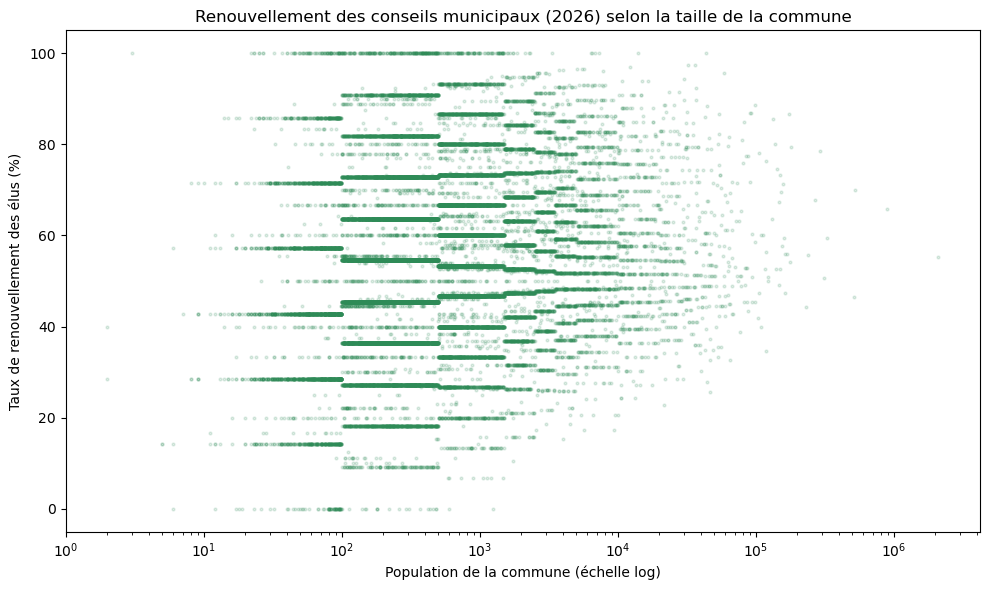

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["population"], df["taux_renouvellement"], s=4, alpha=0.15, color="seagreen")

ax.set_xscale("log")
ax.set_xlabel("Population de la commune (échelle log)")
ax.set_ylabel("Taux de renouvellement des élus (%)")
ax.set_title("Renouvellement des conseils municipaux (2026) selon la taille de la commune")

plt.tight_layout()
plt.savefig("renouvellement_vs_population.png", dpi=150)
plt.show()

### Avec les moyennes et médianes

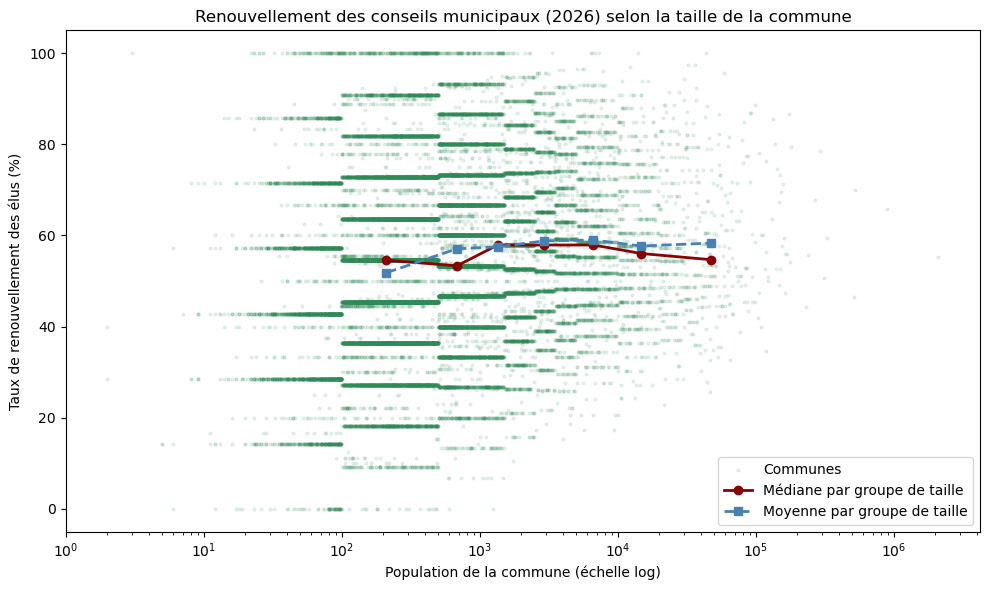

In [38]:

# --- Découpage en 20 groupes de tailles de population ---
# qcut = groupes avec un nombre égal de communes chacun (recommandé ici,
# car la distribution des populations est très asymétrique : sans ça,
# la plupart des communes tomberaient dans un seul groupe)
# df["groupe_taille"] = pd.qcut(df["population"], q=20, duplicates="drop")

# Alternative (à utiliser à la place si tu préfères des tranches de
# population égales sur l'échelle log plutôt qu'un nombre égal de communes) :
# bornes = np.logspace(np.log10(df["population"].min()), np.log10(df["population"].max()), 21)
# df["groupe_taille"] = pd.cut(df["population"], bins=bornes)

# --- Statistiques par groupe ---
stats_par_groupe = (
    df.groupby("groupe_taille", observed=True)
    .agg(
        population_mediane=("population", "median"),
        taux_renouvellement_moyen=("taux_renouvellement", "mean"),
        taux_renouvellement_median=("taux_renouvellement", "median"),
        nb_communes=("code_insee", "count"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

# le nuage de points original en fond
ax.scatter(df["population"], df["taux_renouvellement"], s=4, alpha=0.1, color="seagreen", label="Communes")

# médiane par groupe de taille
ax.plot(
    stats_par_groupe["population_mediane"],
    stats_par_groupe["taux_renouvellement_median"],
    color="darkred", marker="o", linewidth=2, label="Médiane par groupe de taille",
)

# moyenne par groupe de taille
ax.plot(
    stats_par_groupe["population_mediane"],
    stats_par_groupe["taux_renouvellement_moyen"],
    color="steelblue", marker="s", linewidth=2, linestyle="--", label="Moyenne par groupe de taille",
)

ax.set_xscale("log")
ax.set_xlabel("Population de la commune (échelle log)")
ax.set_ylabel("Taux de renouvellement des élus (%)")
ax.set_title("Renouvellement des conseils municipaux (2026) selon la taille de la commune")
ax.legend()

plt.tight_layout()
plt.savefig("renouvellement_vs_population_avec_tendance.png", dpi=150)
plt.show()

### Comparaison 2020 / 2026

### Analyse Rural VS Urbain

### Distribution du taux de renouvellement par groupe de taille

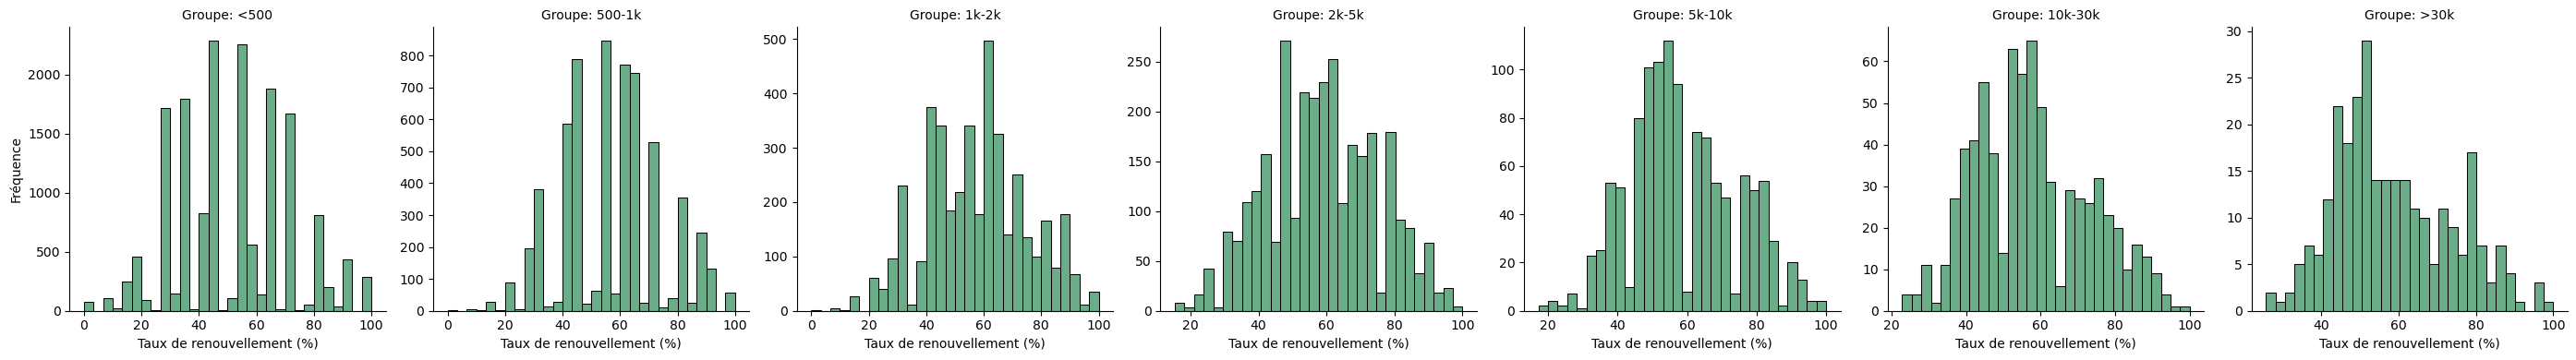

In [48]:

# Graphique en facettes
g = sns.FacetGrid(df, col='groupe_taille', col_wrap=7, height=4, sharey=False, sharex=False)
g.map(sns.histplot, 'taux_renouvellement', bins=30, alpha=0.7, color='seagreen')
g.set_titles('Groupe: {col_name}')
g.set_axis_labels('Taux de renouvellement (%)', 'Fréquence')

plt.tight_layout()
plt.show()

### Boxplot par groupe de taille

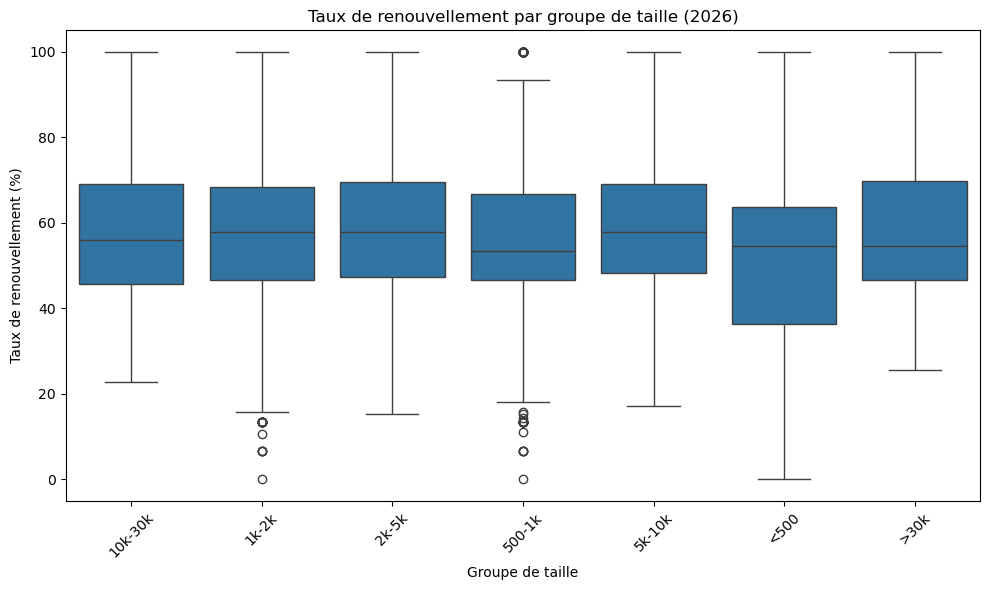

In [42]:

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='groupe_taille',
    y='taux_renouvellement',
    order=sorted(df['groupe_taille'].unique())  # Trie les groupes
)
plt.title("Taux de renouvellement par groupe de taille (2026)")
plt.xlabel("Groupe de taille")
plt.ylabel("Taux de renouvellement (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Calcul du taux de correlation entre taille de commune et taux de renouvellement

In [57]:
from scipy.stats import pearsonr

# Convertir en numérique et nettoyer les valeurs manquantes
pop = pd.to_numeric(df['population'], errors='coerce')
taux = pd.to_numeric(df['taux_renouvellement'], errors='coerce')

# Aligner les séries
pop_clean = pop.dropna()
taux_clean = taux.loc[pop_clean.index].dropna()

# Calculer corrélation + p-value
corr, p_value = pearsonr(pop_clean, taux_clean)

# --- INTERPRÉTATION ---
print("\n" + "="*60)
print("📊 ANALYSE STATISTIQUE : Population vs Taux de renouvellement")
print("="*60)

# 1. Valeurs brutes
print(f"\n🔢 Corrélation de Pearson (r) : {corr:.4f}")
print(f"   p-value : {p_value:.4e}")

# 2. Interprétation de la force de la corrélation
if abs(corr) < 0.1:
    force = "NÉGLIGEABLE"
elif abs(corr) < 0.3:
    force = "FAIBLE"
elif abs(corr) < 0.5:
    force = "MODÉRÉE"
else:
    force = "FORTE"

sens = "négative" if corr < 0 else "positive"
print(f"\n📈 Sens et force : Corrélation {sens} et {force}")

# 3. Interprétation de la p-value
seuil = 0.05
significatif = p_value < seuil
print(f"\n📊 Significativité statistique (seuil α = {seuil}) :")
if significatif:
    print("   ✅ La corrélation est STATISTIQUEMENT SIGNIFICATIVE")
    print("   → Il existe une relation linéaire entre les deux variables.")
else:
    print("   ❌ La corrélation n'est PAS statistiquement significative")
    print("   → On ne peut pas conclure à une relation linéaire.")

# 4. Interprétation dans votre contexte
print("\n💡 INTERPRÉTATION DANS VOTRE CONTEXTE :")
print("   • Si r > 0 : Plus la commune est grande, plus le taux de renouvellement tend à")
print("     "+("augmenter" if corr > 0 else "diminuer")+f" (relation {force.lower()}).")
print("   • Si r ≈ 0 : La taille de la commune n'a pas de lien linéaire avec le")
print("     taux de renouvellement des élus.")
print("   • p-value < 0.05 : Résultat fiable (risque d'erreur < 5%).")
print("   • p-value ≥ 0.05 : Résultat non concluant (échantillon trop petit ou relation non linéaire).")

print("\n" + "="*60)


📊 ANALYSE STATISTIQUE : Population vs Taux de renouvellement

🔢 Corrélation de Pearson (r) : 0.0236
   p-value : 2.5272e-05

📈 Sens et force : Corrélation positive et NÉGLIGEABLE

📊 Significativité statistique (seuil α = 0.05) :
   ✅ La corrélation est STATISTIQUEMENT SIGNIFICATIVE
   → Il existe une relation linéaire entre les deux variables.

💡 INTERPRÉTATION DANS VOTRE CONTEXTE :
   • Si r > 0 : Plus la commune est grande, plus le taux de renouvellement tend à
     augmenter (relation négligeable).
   • Si r ≈ 0 : La taille de la commune n'a pas de lien linéaire avec le
     taux de renouvellement des élus.
   • p-value < 0.05 : Résultat fiable (risque d'erreur < 5%).
   • p-value ≥ 0.05 : Résultat non concluant (échantillon trop petit ou relation non linéaire).



#### Import de la position des départements